[Данные о персонажах «Симпсонов»](https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset "Ссылка на датасет")

In [1]:
import torch, pandas as pd, numpy as np, time, os
import matplotlib.pyplot as plt, seaborn as sns
import torchvision as tv
from torchsummary import summary
from torchvision import datasets

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Загрузка и получение данных

In [ ]:
file_path = '/content/drive/MyDrive/DFD_Учёба/Datasets/simpsons-characters-dataset.zip'
target_dir = '/content/data/datasets/simpsons-characters-dataset'
os.makedirs(target_dir, exist_ok=True)
print(f"Целевая директория создана: {target_dir}")

Целевая директория создана: /content/data/datasets/simpsons-characters-dataset


In [ ]:
# Распаковка архива (в этом архиве дублирующая папка предварительно удалена)
print("Начинаем распаковку...")
!unzip -q "{file_path}" -d "{target_dir}"  # -q — тихий режим
print("Распаковка завершена!")

Начинаем распаковку...
Распаковка завершена!


In [ ]:
# загрузка датасета в свой личный content Google Colab через официальный инструмент от Kaggle
"""import kagglehub
path = kagglehub.dataset_download(
    "alexattia/the-simpsons-characters-dataset",
    output_dir="/content/data/datasets/simpsons-characters-dataset/"
)
print("Датасет сохранён в:", path)


# Удаление дублирующей подпапки: simpsons_dataset (определил только после того как произвел eda классов)
import os
extra_folder = "/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/simpsons_dataset" # путь дублирующей папки
if os.path.exists(extra_folder):
    !rm -rf "{extra_folder}"
    print("Лишняя папка удалена через командную строку.")"""

'import kagglehub\npath = kagglehub.dataset_download(\n    "alexattia/the-simpsons-characters-dataset",\n    output_dir="/content/data/datasets/simpsons-characters-dataset/"\n)\nprint("Датасет сохранён в:", path)\n\n\n# Удаление дублирующей подпапки: simpsons_dataset (определил только после того как произвел eda классов)\nimport os\nextra_folder = "/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/simpsons_dataset" # путь дублирующей папки\nif os.path.exists(extra_folder):\n    !rm -rf "{extra_folder}"\n    print("Лишняя папка удалена через командную строку.")'

In [ ]:
from torchvision import transforms
# Трансформации для обучающей выборки (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),  # Приводим все изображения к одному размеру
    transforms.RandomHorizontalFlip(p=0.5),  # Случайное отражение по горизонтали
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Изменение яркости и контраста
    transforms.ToTensor(),  # Конвертируем в тензор PyTorch
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # Нормализация (стандартные значения для ImageNet) - рекомендованные
                         std=[0.229, 0.224, 0.225])  # Стандартные отклонения
])

# Трансформации для валидационной выборки (БЕЗ АУГМЕНТАЦИИ)!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                     std=[0.229, 0.224, 0.225])
])


In [ ]:
# ИСПОЛЬЗУЮ МЕТОД ImageFolder. Получаю хранилище данных
from torchvision import datasets
full_dataset_path = '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/'

# Формирую датасет
full_dataset = datasets.ImageFolder(
    root=full_dataset_path,
    transform=None # НИЧЕГО не трансформирую т.к это общее хранилище - ImageFolder всех картинок. ДО РАЗДЕЛЕНИЯ на Train и Test
)
# Список классов
class_names = full_dataset.classes
print(f"Всего классов: {len(class_names)}")
print(f"Классы: {class_names}")

Всего классов: 42
Классы: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'carl_carlson', 'charles_montgomery_burns', 'chief_wiggum', 'cletus_spuckler', 'comic_book_guy', 'disco_stu', 'edna_krabappel', 'fat_tony', 'gil', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lionel_hutz', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'martin_prince', 'mayor_quimby', 'milhouse_van_houten', 'miss_hoover', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'otto_mann', 'patty_bouvier', 'principal_skinner', 'professor_john_frink', 'rainier_wolfcastle', 'ralph_wiggum', 'selma_bouvier', 'sideshow_bob', 'sideshow_mel', 'snake_jailbird', 'troy_mcclure', 'waylon_smithers']


In [ ]:
full_dataset

Dataset ImageFolder
    Number of datapoints: 20933
    Root location: /content/data/datasets/simpsons-characters-dataset/simpsons_dataset/

In [ ]:
# Проверка + пример первых трех изображений с указанием путей и их target(класс)
full_dataset.samples[:3]

[('/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0000.jpg',
  0),
 ('/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0001.jpg',
  0),
 ('/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0002.jpg',
  0)]

## EDA представленных классов

In [ ]:
from collections import Counter

# Расчёт количество изображений по классам
class_counts = Counter(full_dataset.targets) # Словарь с расчетами по каждому классу. Классы индексированы с 0-41

In [ ]:
pd.DataFrame(sorted(class_counts.items(), key=lambda x: x[1], reverse=True), columns=['class_name', 'count_images']).head(10)

,class_name,count_images
0,15,2246
1,28,1454
2,27,1452
3,20,1354
4,4,1342
5,22,1291
6,17,1206
7,32,1194
8,6,1193
9,25,1079


In [ ]:
# Просмотр (ТАБЛИЦА) и расчет изображений которые приходится на каждый класс. КЛАССЫ НЕСБАЛАНСИРОВАНЫ!!!.
data = [
    {'class': full_dataset.classes[class_idx], 'count_class': count}
    for class_idx, count in class_counts.items()
]
df_classes = pd.DataFrame(data).sort_values(by='count_class', ascending=False)
df_classes

,class,count_class
15,homer_simpson,2246
28,ned_flanders,1454
27,moe_szyslak,1452
20,lisa_simpson,1354
4,bart_simpson,1342
22,marge_simpson,1291
17,krusty_the_clown,1206
32,principal_skinner,1194
6,charles_montgomery_burns,1193
25,milhouse_van_houten,1079


In [ ]:
# Распределение классов. Явный дисбаланс классов.
def chart_histplot_class(Dataset_ImageFolder):
  sns.set_style('darkgrid')
  plt.figure(figsize=(20, 4))
  sns.histplot(Dataset_ImageFolder.targets, kde=True)
  all_classes = sorted(set(Dataset_ImageFolder.targets))
  plt.xticks(all_classes)  # Устанавка деления оси X
  plt.title('Распределение классов датасета simpsons')
  plt.xlabel('Class')
  plt.grid(True, alpha=0.0)
  plt.text(x=0.02, y=0.9, s = f'Всего изображений: {len(Dataset_ImageFolder)}', fontsize=10, fontweight='bold', transform=plt.gca().transAxes);

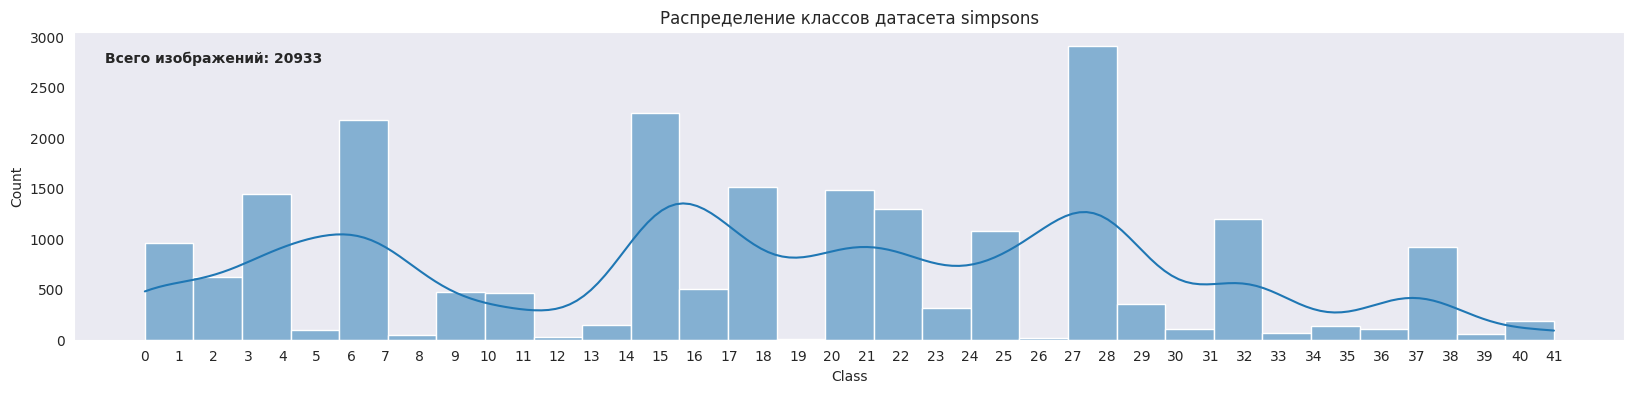

In [ ]:
chart_histplot_class(full_dataset)

## train_test_split/ Разделение данных

In [ ]:
# разделим ПУТИ к картинкам на train и val в отношении 70 на 30 для каждого класса
import glob
from sklearn.model_selection import train_test_split

data_dir = "/content/data/datasets/simpsons-characters-dataset/simpsons_dataset" # путь к датасету
data_image_paths = glob.glob(f"{data_dir}/**/*.jpg", recursive=True) # Получаем список путей. Рекурсивный подход: recursive=True - если сложная структура подпапок, **: поиск во всех вложенных папках.
data_image_labels = [path.split('/')[-2] for path in data_image_paths] # Получаем классы изображений: н-р patty_bouvier
train_files_path, val_files_path = train_test_split(
    data_image_paths,
    test_size=0.3,
    stratify=data_image_labels # стратификация по названию класса
)

print(f"Изображений в train: {len(train_files_path)}\nИзображений в val: {len(val_files_path)}")

Изображений в train: 14653
Изображений в val: 6280


In [ ]:
data_image_paths[:3]

['/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0786.jpg',
 '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0080.jpg',
 '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/abraham_grampa_simpson/pic_0119.jpg']

In [ ]:
train_imagefolder = tv.datasets.ImageFolder(
    data_dir,
    transform=train_transforms,
    is_valid_file=lambda x: x in train_files_path
)

val_imagefolder = tv.datasets.ImageFolder(
    data_dir,
    transform=val_transforms,
    is_valid_file=lambda x: x in val_files_path
)

In [ ]:
train_imagefolder

Dataset ImageFolder
    Number of datapoints: 14653
    Root location: /content/data/datasets/simpsons-characters-dataset/simpsons_dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

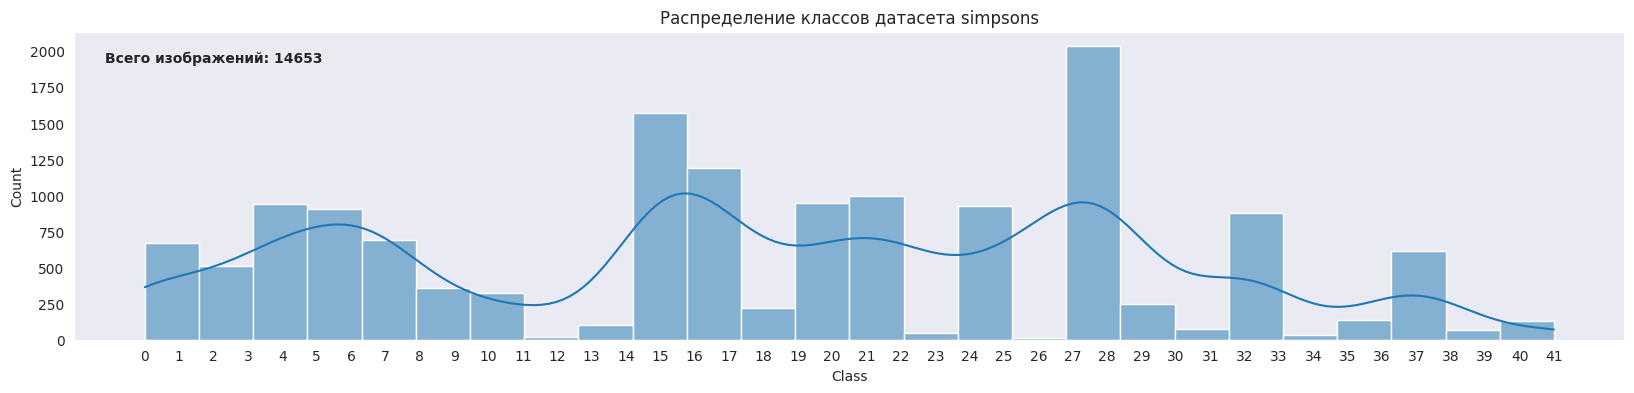

In [ ]:
# Проверка на обучающей выборке. После разделение данных соотношение классов не поменялось
chart_histplot_class(train_imagefolder)

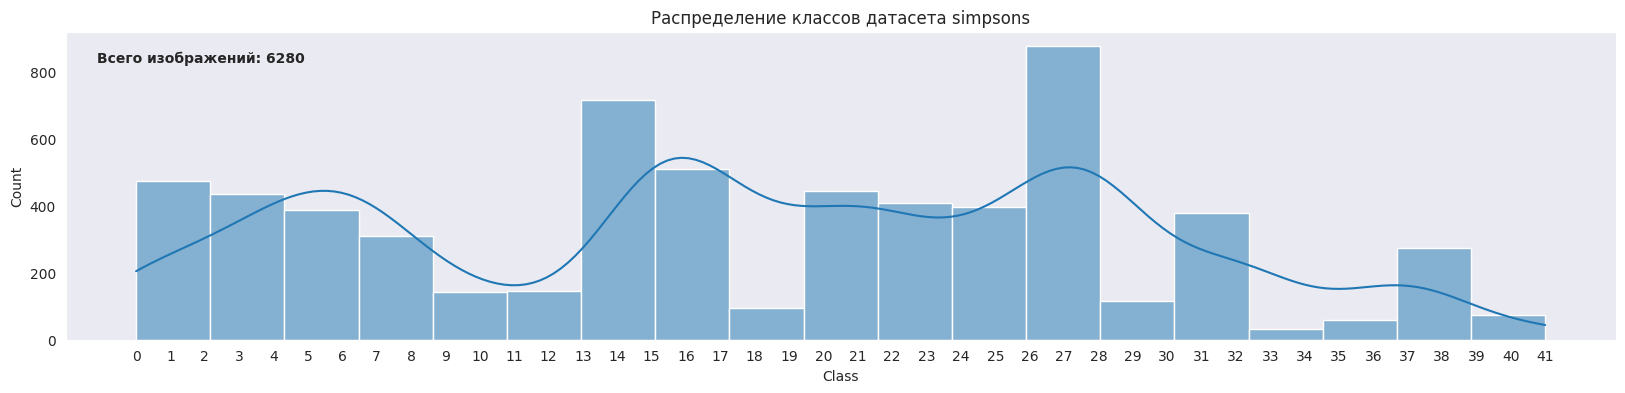

In [ ]:
# Проверка на тестовой выборке. После разделение данных соотношение классов не поменялось
chart_histplot_class(val_imagefolder)

In [ ]:
batch_size=64

train_Loader = torch.utils.data.DataLoader(train_imagefolder, batch_size=batch_size, shuffle=True, drop_last=True) # отбразывает неполный батч в конце эпохи
val_Loader = torch.utils.data.DataLoader(val_imagefolder, batch_size=batch_size, shuffle=False)

In [ ]:
for images, labels in train_Loader:
  print(f"Размер батча: {images.shape}")
  print(f"Размер одного изображения: {images[0].shape}")
  break  # Выходим после первого батча

print(f'Общее количество батчей: {len(train_Loader)}\n'
      f'Общее количество изображений в датасете: {len(train_Loader.dataset)}\n')

Размер батча: torch.Size([64, 3, 224, 224])
Размер одного изображения: torch.Size([3, 224, 224])
Общее количество батчей: 228
Общее количество изображений в датасете: 14653



## МОДЕЛЬ. efficientnet_b0. Архитектура

In [ ]:
model_efficientnet_b0 = tv.models.efficientnet_b0(pretrained=True)
# model_efficientnet_b0 = tv.models.efficientnet_b0(weights=tv.models.EfficientNet_B0_Weights.IMAGENET1K_V1)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


In [ ]:
def summary_(model, input_size=(3, 224, 224) ):
  device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
  model = model.to(device)  # Перемещаем модель на устройство
  return summary(model.to(device), input_size=input_size)

In [ ]:
summary_(model_efficientnet_b0)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

## **Transfer Learning | `Feature Extraction`**

In [ ]:
model_efficientnet_b0.classifier # классификатор модели (голова)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [ ]:
# model.classifier[1] = torch.nn.Linear(1280, 42) альтернативный вариант замены

new_out_features = len(full_dataset.classes) # Определение число классов в датасете
out_features = model_efficientnet_b0.classifier[1].in_features # in_features последнего слоя
model_efficientnet_b0.classifier[1] = torch.nn.Linear(out_features, new_out_features) # замена размерности выходного вектора (размерность = количество классов датасета)
print(model_efficientnet_b0.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=42, bias=True)
)


**Обучение**

In [ ]:
# Фнкция потерь.
loss = torch.nn.CrossEntropyLoss()

In [ ]:
# Предварительно создается ОПТИМАЙЗЕР, а потом ШЕДУЛЕР/ы(планировщики)
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [ ]:
optimizer_adam = optimizer(model=model_efficientnet_b0, lr=0.001)

**`ШЕДУЛЕР/ы(планировщики)`**.
*   ПРИ ПРИМЕНЕНИИ ШЕДУЛЕРА НУЖНО ПРЕДВАРИТЕЛЬНО ЕГО ДОБАВИТЬ В ФУНКЦИЮ ОБУЧЕНИЯ
*   Для StepLR, ExponentialLR, CosineAnnealingLR в функции ОБУЧЕНИЯ НУЖНО ВЫЗЫВАТЬ после завершения эпохи обучения (после цикла по train_loader, но до валидации)
*   Для ReduceLROnPlateau в функции ОБУЧЕНИЯ НУЖНО ВЫЗЫВАТЬ после валидации, передавая метрику (loss или accuracy):






In [ ]:
# StepLR/ уменьшает LR каждые step_size эпох на коэффициент gamma (например при step_size=10 - эпох, gamma= 0.1 - уменьшает lr на 10)
# ExponentialLR/ экспоненциальное уменьшение,  каждый шаг: lr = lr * 0.95
# ReduceLROnPlateau/уменьшает LR, если метрика не улучшается (patience=5 - ждём 5 эпох без улучшений при factor=0.5 уменьшает lr в 2 раза)
# CosineAnnealingLR/ T_max=100     период цикла в эпохах (100 эпох)

schedulers_1 = torch.optim.lr_scheduler.StepLR(optimizer=optimizer_adam, step_size=3, gamma=0.1)

# schedulers_2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_adam_2, T_max=5, eta_min=1e-6) # будет использован ниже

`Функция обучения`

In [ ]:
def train_model(model, train_loader, val_loader, optimizer_, scheduler, num_epochs=10):
    train_losses = []
    val_losses = []

    # Определяем устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)  # Перемещаем модель на устройство

    for ep in range(num_epochs):
        # Обучение (train)
        train_iters, train_passed = 0, 0
        train_loss, train_acc = 0., 0.
        start = time.time()

        model.train()
        for X, y in train_loader: # ДАННЫЕ ДЛЯ ОБУЧЕНИЯ
            X = X.to(device)  # Переносим на устройство
            y = y.to(device)  # Переносим на устройство

            optimizer_.zero_grad()
            y_pred = model(X)
            l = loss(y_pred, y)
            l.backward()
            optimizer_.step()
            train_loss += l.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item()
            train_iters += 1
            train_passed += len(X)

        scheduler.step() # ВАЖНО: обновляем StepLR, ExponentialLR, CosineAnnealingLR после обучения, но ДО валидации

        # Валидация (test)
        test_iters, test_passed = 0, 0
        test_loss, test_acc = 0., 0.
        model.eval()
        with torch.no_grad():  # Отключаем вычисление градиентов
            for X, y in val_loader:      # ТЕСТОВЫЕ ДАННЫЕ
                X = X.to(device)  # Обязательно переносим на устройство!
                y = y.to(device)  # Обязательно переносим на устройство!

                y_pred = model(X)
                l = loss(y_pred, y)
                test_loss += l.item()
                test_acc += (y_pred.argmax(dim=1) == y).sum().item()
                test_iters += 1
                test_passed += len(X)

        # Усредняем потери
        avg_train_loss = train_loss / train_iters
        avg_test_loss = test_loss / test_iters

        # scheduler.step(avg_test_loss) # ВАЖНО: ВЫЗЫВАТЬ после валидации

        train_losses.append(avg_train_loss)
        val_losses.append(avg_test_loss)

        print("ep: {}, taked: {:.3f}, train_loss: {:.4f}, train_accuracy: {:.4f}, test_loss: {:.4f}, test accuracy: {:.4f}".format(
            ep,
            time.time() - start,
            avg_train_loss,
            train_acc / train_passed,
            avg_test_loss,
            test_acc / test_passed
        ))

    return train_losses, val_losses

In [ ]:
train_losses_StepLR, val_losses_StepLR = train_model(model=model_efficientnet_b0, train_loader=train_Loader, val_loader=val_Loader, optimizer_=optimizer_adam, scheduler=schedulers_1)

# 2. Сохраняем в JSON
import json

with open('results_efficientnet_b0_StepLR.json', 'w') as f:
    json.dump({
        'train_losses': train_losses_StepLR,
        'val_losses': val_losses_StepLR
    }, f, indent=4)

ep: 0, taked: 189.234, train_loss: 0.5933, train_accuracy: 0.8600, test_loss: 0.1957, test accuracy: 0.9530
ep: 1, taked: 189.385, train_loss: 0.1686, train_accuracy: 0.9591, test_loss: 0.2007, test accuracy: 0.9449
ep: 2, taked: 190.146, train_loss: 0.1127, train_accuracy: 0.9692, test_loss: 0.1582, test accuracy: 0.9621
ep: 3, taked: 189.087, train_loss: 0.0434, train_accuracy: 0.9883, test_loss: 0.1101, test accuracy: 0.9771
ep: 4, taked: 189.380, train_loss: 0.0235, train_accuracy: 0.9943, test_loss: 0.1027, test accuracy: 0.9785
ep: 5, taked: 190.389, train_loss: 0.0159, train_accuracy: 0.9958, test_loss: 0.1024, test accuracy: 0.9793
ep: 6, taked: 189.321, train_loss: 0.0115, train_accuracy: 0.9972, test_loss: 0.1016, test accuracy: 0.9796
ep: 7, taked: 189.554, train_loss: 0.0105, train_accuracy: 0.9977, test_loss: 0.1019, test accuracy: 0.9796
ep: 8, taked: 189.815, train_loss: 0.0114, train_accuracy: 0.9976, test_loss: 0.1031, test accuracy: 0.9793
ep: 9, taked: 189.565, train

## Сохранение результатов. График. `ВЫВОДЫ`

In [ ]:
import json

with open('results_efficientnet_b0_StepLR.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_model_efficientnet_b0_StepLR = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_model_efficientnet_b0_StepLR

,Epoch,Train Loss,Validation Loss
0,0,0.593332,0.195655
1,1,0.168621,0.200669
2,2,0.112668,0.158160
3,3,0.043439,0.110092
4,4,0.023519,0.102673
5,5,0.015880,0.102396
6,6,0.011506,0.101576
7,7,0.010543,0.101871
8,8,0.011400,0.103051
9,9,0.010768,0.102110


In [ ]:
def chart_plot(df):
  plt.figure(figsize=(10, 6))
  plt.plot(df['Epoch'], df['Train Loss'], label='Train Loss', marker='o')
  plt.plot(df['Epoch'], df['Validation Loss'], label='Validation Loss', marker='s')
  plt.title('Training and Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

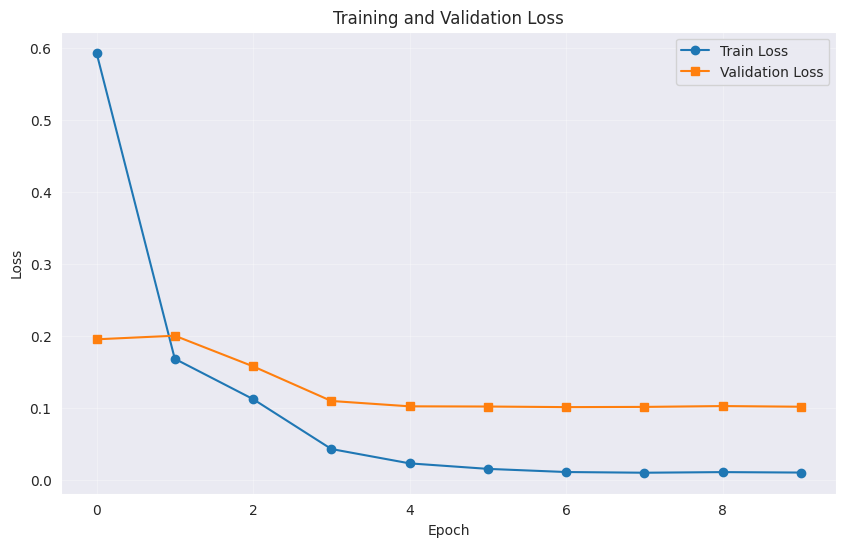

In [ ]:
chart_plot(df_model_efficientnet_b0_StepLR)



*   (эпохи 0–2): быстрое обучение
*   На эпохе 3 срабатывает StepLR: LR снижается в 10 раз (gamma=0.1)
*   train_loss резко падает: 0.1127 → 0.0434
*   test_loss продолжает снижаться: 0.1582 → 0.1101
*   accuracy заметно растёт
*   снижение LR позволяет модели перейти от грубого поиска минимума к тонкой настройке
*   test_loss стабилизируется около 0.102–0.103
*   test_accuracy держится стабильно на уровне 0.979–0.980.
*   нет расхождения train/test loss — нет переобучения + стабильность
*   в сравнении с CosineAnnealingLR (результат ниже) StepLR показывает лучшие и стабильные результаты




## **Transfer Learning | `Fine‑Tuning`**

In [ ]:
model_efficientnet_b0_Fine_Tuning = tv.models.efficientnet_b0(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
#Доступ к двум последним свёрточным блокам сети.
model_efficientnet_b0_Fine_Tuning.features[-2:]

Sequential(
  (7): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(192, 1152, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(1152, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(1152, 1152, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=1152, bias=False)
          (1): BatchNorm2d(1152, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (2): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(1152, 48, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(48, 1152, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (3): Conv2dNormActivation(
          (0): Conv2d(1152, 320

In [ ]:
# Тюнинг.  Эти два блока отвечают за высокоуровневые признаки."Размораживаю" блоки, веса буду обновляться, вычесляеться градиент!
model_efficientnet_b0_Fine_Tuning.classifier[1] = torch.nn.Linear(1280, 42) # меняю выходной слой на 42 признака

# Размораживаю последние 2 блока
for param in model_efficientnet_b0_Fine_Tuning.features[-2:].parameters():
    param.requires_grad = True # процесс обратного распространения ошибки (backpropagation) включен!

In [ ]:
# Стало Trainable params: 4,061,350.
# Было обученных Trainable params: 5,288,548.
# ИТОГ: будут обучаться 1,227,198 параметров
summary_(model_efficientnet_b0_Fine_Tuning)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

**Обучение**

In [ ]:
optimizer_adam_2 = optimizer(model=model_efficientnet_b0_Fine_Tuning, lr=0.001)

In [ ]:
schedulers_2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_adam_2, T_max=5, eta_min=1e-6)

In [ ]:
# ОБУЧЕНИЕ
train_losses_CosineAnnealingLR, val_losses_CosineAnnealingLR = train_model(
    model=model_efficientnet_b0_Fine_Tuning,
    train_loader=train_Loader,
    val_loader=val_Loader,
    optimizer_=optimizer_adam_2,
    scheduler=schedulers_2)

# 2. Сохраняем в JSON
import json

with open('results_model_efficientnet_b0_CosineAnnealingLR_Fine_Tuning.json', 'w') as f:
    json.dump({
        'train_losses': train_losses_CosineAnnealingLR,
        'val_losses': val_losses_CosineAnnealingLR
    }, f, indent=4)

ep: 0, taked: 189.893, train_loss: 0.5765, train_accuracy: 0.8614, test_loss: 0.2412, test accuracy: 0.9401
ep: 1, taked: 187.846, train_loss: 0.1471, train_accuracy: 0.9618, test_loss: 0.1710, test accuracy: 0.9573
ep: 2, taked: 187.146, train_loss: 0.0718, train_accuracy: 0.9807, test_loss: 0.1149, test accuracy: 0.9756
ep: 3, taked: 188.047, train_loss: 0.0288, train_accuracy: 0.9923, test_loss: 0.0977, test accuracy: 0.9788
ep: 4, taked: 187.843, train_loss: 0.0110, train_accuracy: 0.9975, test_loss: 0.0914, test accuracy: 0.9803
ep: 5, taked: 186.793, train_loss: 0.0090, train_accuracy: 0.9981, test_loss: 0.0918, test accuracy: 0.9803
ep: 6, taked: 186.928, train_loss: 0.0080, train_accuracy: 0.9981, test_loss: 0.0929, test accuracy: 0.9817
ep: 7, taked: 188.060, train_loss: 0.0122, train_accuracy: 0.9962, test_loss: 0.1245, test accuracy: 0.9745
ep: 8, taked: 186.555, train_loss: 0.0960, train_accuracy: 0.9735, test_loss: 0.2108, test accuracy: 0.9508
ep: 9, taked: 188.503, train

## Сохранение результатов. График. `ВЫВОДЫ`

In [ ]:
import json

with open('results_model_efficientnet_b0_CosineAnnealingLR_Fine_Tuning.json', 'r') as f:
    results = json.load(f)

# Преобразуем в DataFrame для удобного просмотра
df_model_efficientnet_b0_CosineAnnealingLR_Fine_Tuning = pd.DataFrame({
    'Epoch': range(len(results['train_losses'])),
    'Train Loss': results['train_losses'],
    'Validation Loss': results['val_losses']
})

df_model_efficientnet_b0_CosineAnnealingLR_Fine_Tuning

,Epoch,Train Loss,Validation Loss
0,0,0.576508,0.241230
1,1,0.147136,0.171035
2,2,0.071818,0.114877
3,3,0.028802,0.097743
4,4,0.011017,0.091400
5,5,0.009015,0.091804
6,6,0.007976,0.092938
7,7,0.012213,0.124540
8,8,0.095974,0.210782
9,9,0.137447,0.178515


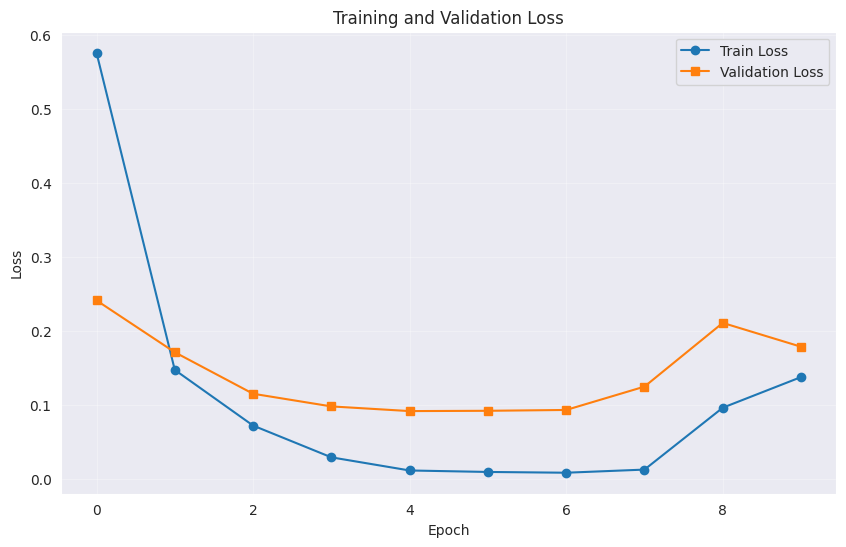

In [ ]:
chart_plot(df_model_efficientnet_b0_CosineAnnealingLR_Fine_Tuning)

*   До 5‑й эпохи модель обучалась и улучшала метрики.
*   Эпохи 7–9: из‑за слишком низкого LR модель дестабилизируется — train_loss и test_loss растут, accuracy падает.
*   Эффект CosineAnnealingLR: на ранних эпохах LR высокий — модель быстро обучается. С 6 по 9 эпохам LR уже сильно снижен (по косинусоиде).

## Аугментация train данных, при которых итоговое качество на валидации будет сильно хуже.

In [ ]:
# Буду использовать модель из Transfer Learning | Feature Extraction

In [ ]:
print(train_files_path[:3])
print(val_files_path[:3])

['/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/sideshow_bob/pic_0815.jpg', '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/marge_simpson/pic_0148.jpg', '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/ned_flanders/pic_1219.jpg']
['/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/chief_wiggum/pic_0765.jpg', '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/sideshow_bob/pic_0716.jpg', '/content/data/datasets/simpsons-characters-dataset/simpsons_dataset/homer_simpson/pic_0910.jpg']


In [ ]:
# Плохая Аугментация
train_bad_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(size=224, scale=(0.3, 0.7)),# случайная обрезка от 30 до 70%
    transforms.RandomHorizontalFlip(p=0.8),                  # частый флип
    transforms.ColorJitter(brightness=0.9, contrast=0.9),    # сильные цветовые искажения
    transforms.GaussianBlur(kernel_size=15),                 # заметное размытие
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],         # ВЫПОЛНЯЮ НОРМАЛИЗАЦИЮ В КОНЦЕ!!!!!!!!!!!!!!!! (делаю умышленно для сравнения с первой моделью
                 std=[0.229, 0.224, 0.225])
])

In [ ]:
# Трансформация
train_bad_imagefolder = tv.datasets.ImageFolder(
    data_dir,
    transform=train_bad_transforms,
    is_valid_file=lambda x: x in train_files_path
)

val_imagefolder = tv.datasets.ImageFolder(
    data_dir,
    transform=val_transforms,
    is_valid_file=lambda x: x in val_files_path
)

In [ ]:
sns.set_style(style='white')

def show_images(dataset):
    fig, ax = plt.subplots(
        nrows=2, ncols=3, figsize=(6, 4),
        sharey=True, sharex=True
    )

    for fig_x in ax.flatten():
        idx = np.random.randint(low=0, high=6000)
        img, label = dataset[idx]
        fig_x.set_title(dataset.classes[label])
        fig_x.imshow(img.numpy().transpose((1, 2, 0)))

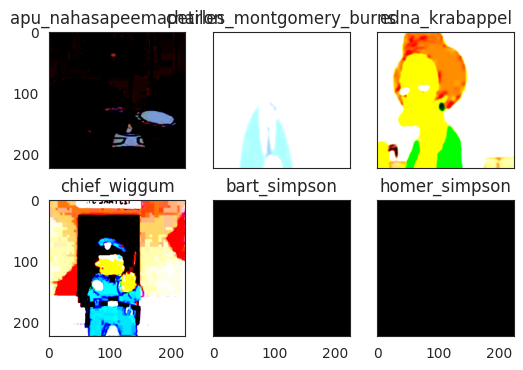

In [ ]:
show_images(train_bad_imagefolder)

In [ ]:
# Подготовка лоадера с плохой аугментацией
batch_size=64

train_Loader_bad = torch.utils.data.DataLoader(train_bad_imagefolder, batch_size=batch_size, shuffle=True, drop_last=True) # отбразывает неполный батч в конце эпохи
val_Loader = torch.utils.data.DataLoader(val_imagefolder, batch_size=batch_size, shuffle=False)

In [ ]:
# Фнкция потерь.
loss = torch.nn.CrossEntropyLoss()

In [ ]:
# Предварительно создается ОПТИМАЙЗЕР, а потом ШЕДУЛЕР/ы(планировщики)
def optimizer(model, lr=0.01):
  return torch.optim.Adam(model.parameters(), lr=lr) # weight_decay=1e-5 - L2 регуляризация

In [ ]:
optimizer_adam_bad = optimizer(model=model_efficientnet_b0, lr=0.001)

In [ ]:
schedulers_1_bad = torch.optim.lr_scheduler.StepLR(optimizer=optimizer_adam_bad, step_size=3, gamma=0.1)

In [ ]:
train_losses_BAD, val_losses_StepLR = train_model(model=model_efficientnet_b0, train_loader=train_Loader_bad, val_loader=val_Loader, optimizer_=optimizer_adam_bad, scheduler=schedulers_1_bad)

# 2. Сохраняем в JSON
import json

with open('results_efficientnet_b0_BAD.json', 'w') as f:
    json.dump({
        'train_losses': train_losses_BAD,
        'val_losses': val_losses_StepLR
    }, f, indent=4)

ep: 0, taked: 520.410, train_loss: 0.9328, train_accuracy: 0.7651, test_loss: 0.4776, test accuracy: 0.8696
ep: 1, taked: 513.748, train_loss: 0.3964, train_accuracy: 0.8921, test_loss: 0.2785, test accuracy: 0.9283
ep: 2, taked: 502.252, train_loss: 0.3099, train_accuracy: 0.9157, test_loss: 0.2102, test accuracy: 0.9444
ep: 3, taked: 497.950, train_loss: 0.2127, train_accuracy: 0.9415, test_loss: 0.1555, test accuracy: 0.9626
ep: 4, taked: 516.476, train_loss: 0.1634, train_accuracy: 0.9550, test_loss: 0.1479, test accuracy: 0.9643
ep: 5, taked: 514.617, train_loss: 0.1458, train_accuracy: 0.9611, test_loss: 0.1337, test accuracy: 0.9677
ep: 6, taked: 514.579, train_loss: 0.1340, train_accuracy: 0.9644, test_loss: 0.1343, test accuracy: 0.9678
ep: 7, taked: 510.127, train_loss: 0.1267, train_accuracy: 0.9661, test_loss: 0.1314, test accuracy: 0.9686
ep: 8, taked: 503.773, train_loss: 0.1310, train_accuracy: 0.9653, test_loss: 0.1267, test accuracy: 0.9705
ep: 9, taked: 494.012, train